<a href="https://colab.research.google.com/github/kerelosgerges/CNN-MODEL/blob/main/Copy_of_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN MODEL

In [ ]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [ ]:
trainpath = "/kaggle/input/intel-image-classification/seg_train/seg_train"
testpath = "/kaggle/input/intel-image-classification/seg_test/seg_test"
validpath = "/kaggle/input/intel-image-classification/seg_pred/seg_pred"

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast,RandomTranslation,RandomBrightness
BATCH_SIZE = 32
IMG_SIZE = (224,224)
train_ds = tf.keras.utils.image_dataset_from_directory(trainpath,seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(testpath,seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
pred_ds = tf.keras.utils.image_dataset_from_directory(validpath,labels=None,label_mode=None,image_size=IMG_SIZE,batch_size=BATCH_SIZE,shuffle=False)
data_augmentation = tf.keras.Sequential([RandomFlip("horizontal"),
                                         RandomRotation(0.1),
                                         RandomZoom(0.1),
                                         RandomContrast(0.1),
                                         RandomBrightness(factor=0.2),
                                         RandomTranslation(0.1, 0.1)])
normalization_layer = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
pred_ds = pred_ds.map(lambda x: normalization_layer(x))
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)
pred_ds  = pred_ds.prefetch(buffer_size=AUTOTUNE)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Found 7301 files.


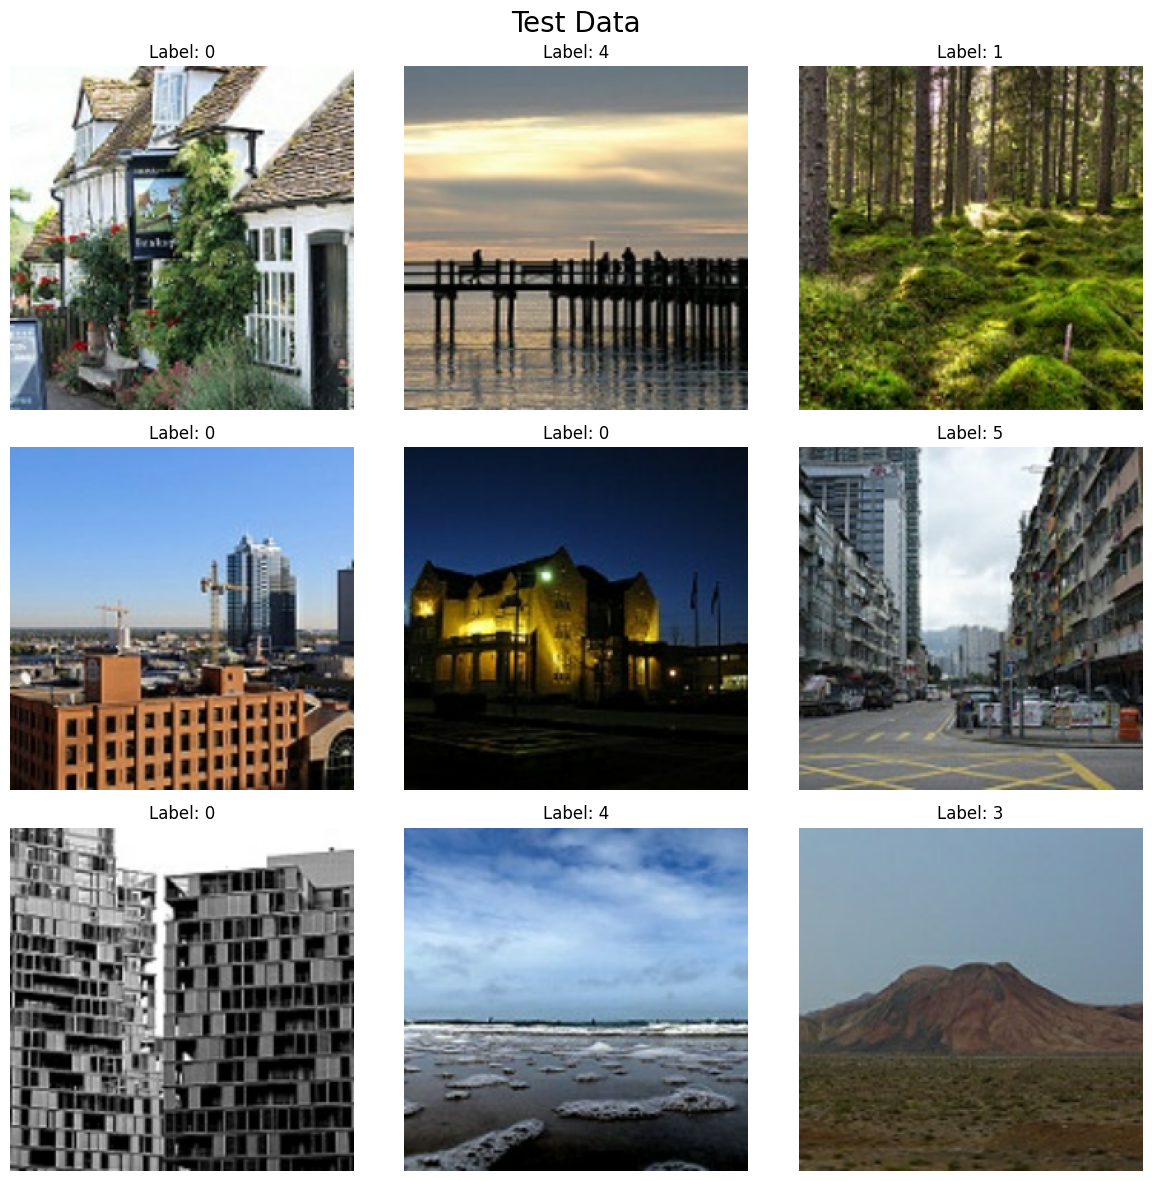

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def show_images(dataset, title="My Images"):
    batch = next(iter(dataset))
    if isinstance(batch, tuple):
        images, labels = batch
    else:
        images = batch
    images = images.numpy()
    images = (images * 255).astype(np.uint8)
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        if isinstance(batch, tuple):
            plt.title(f"Label: {labels[i].numpy()}")
        plt.axis('off')
    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()
show_images(test_ds, "Test Data")


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, InputLayer
IMG_SIZE = (224, 224, 3)
NUM_CLASSES = 6
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=IMG_SIZE)
vgg19_base.trainable = False
model = Sequential(
    [InputLayer(input_shape=IMG_SIZE)
    ,vgg19_base
     ,Flatten()
     ,Dense(512, activation='relu'),
     Dropout(0.5),
     Dense(256, activation='relu'),
     Dropout(0.2),
     Dense(NUM_CLASSES, activation='softmax')
     ]
    )


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,002,822 (125.90 MB)

 Trainable params: 12,978,438 (49.51 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_path = "best_model.keras"
checkpoint_cb = ModelCheckpoint(filepath=checkpoint_path,monitor='val_accuracy',save_best_only=True,save_weights_only=False,verbose=1)
history = model.fit(train_ds,validation_data=test_ds,epochs=10,callbacks=[checkpoint_cb])


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.5595 - loss: 1.0950
Epoch 1: val_accuracy improved from -inf to 0.82533, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 363s 787ms/step - accuracy: 0.5597 - loss: 1.0944 - val_accuracy: 0.8253 - val_loss: 0.4863
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.7454 - loss: 0.6645
Epoch 2: val_accuracy improved from 0.82533 to 0.83300, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 322s 733ms/step - accuracy: 0.7454 - loss: 0.6645 - val_accuracy: 0.8330 - val_loss: 0.4484
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7725 - loss: 0.6016
Epoch 3: val_accuracy improved from 0.83300 to 0.84567, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 389s 749ms/step - accuracy: 0.7726 - loss: 0.6016 - val_accuracy: 0.8457 - val_loss: 0.4197
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.7822 - loss: 0.5659
Epoch 4: val_accuracy

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
model = load_model("best_model.keras")
def plot_history(history):
    h = history.history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h['loss'], label='train loss')
    plt.plot(h['val_loss'], label='val loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h['accuracy'], label='train acc')
    plt.plot(h['val_accuracy'], label='val acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
plot_history(history)

ValueError: File not found: filepath=best_model.keras. Please ensure the file is an accessible `.keras` zip file.

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - accuracy: 0.8717 - loss: 0.3600
Test Loss: 0.3779
Test Accuracy: 0.8660


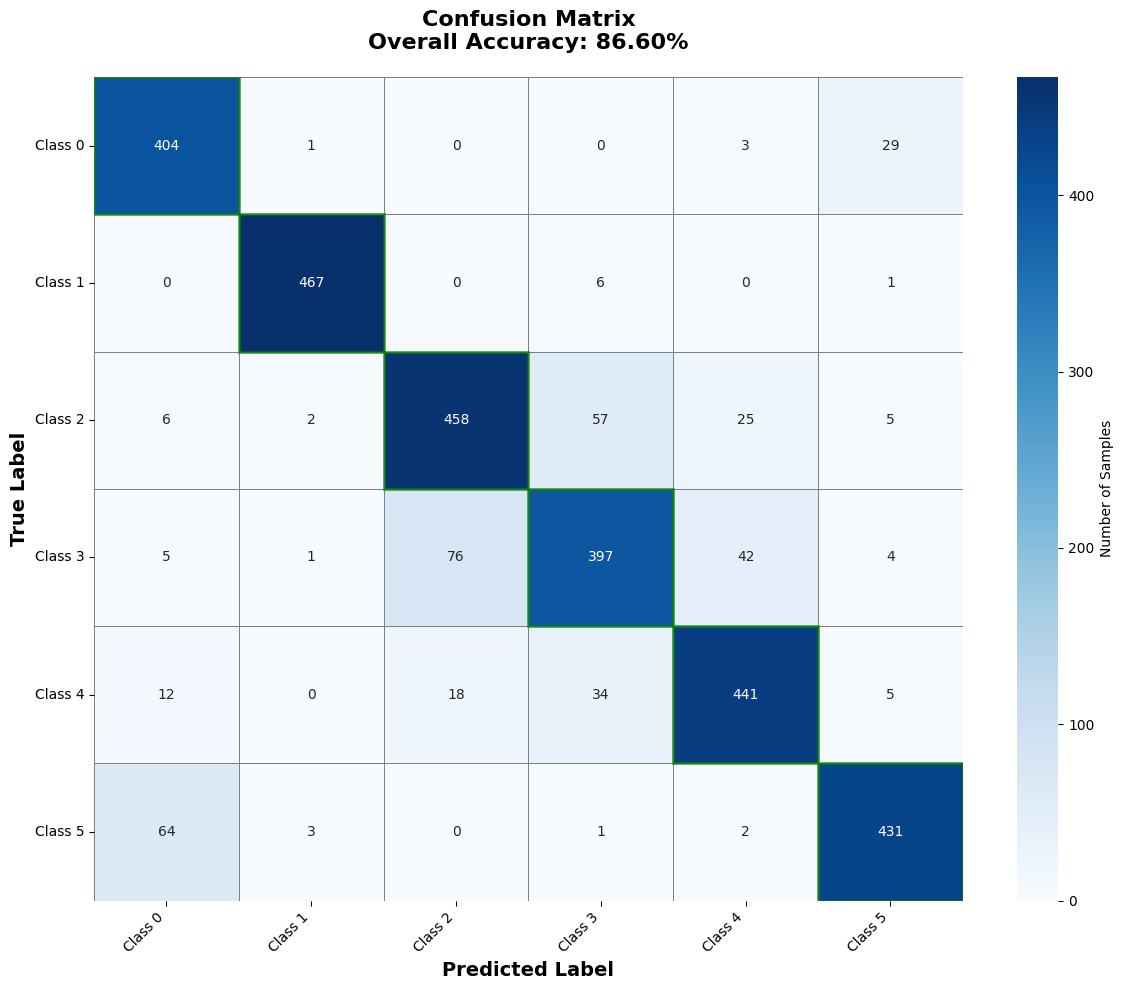


📈 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class_0     0.8228    0.9245    0.8707       437
     Class_1     0.9852    0.9852    0.9852       474
     Class_2     0.8297    0.8282    0.8290       553
     Class_3     0.8020    0.7562    0.7784       525
     Class_4     0.8596    0.8647    0.8622       510
     Class_5     0.9074    0.8603    0.8832       501

    accuracy                         0.8660      3000
   macro avg     0.8678    0.8699    0.8681      3000
weighted avg     0.8665    0.8660    0.8656      3000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
loss, acc = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
def evaluate_and_plot(model, test_ds):
    all_true = []
    all_preds = []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        true_labels = y_batch.numpy().flatten()
        pred_labels = np.argmax(preds, axis=1)
        all_true.extend(true_labels)
        all_preds.extend(pred_labels)
    y_true = np.array(all_true)
    y_pred = np.array(all_preds)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar_kws={'label': 'Number of Samples'},linewidths=0.5, linecolor='gray')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    accuracy = np.trace(cm) / np.sum(cm) * 100
    plt.title(f'Confusion Matrix\nOverall Accuracy: {accuracy:.2f}%',fontsize=16, fontweight='bold', pad=20)
    class_names = [f'Class {i}' for i in sorted(np.unique(y_true))]
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names, rotation=0)
    ax.grid(False)
    for i in range(len(cm)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,edgecolor='green', lw=2, alpha=0.7))
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60)
    print("📈 DETAILED CLASSIFICATION REPORT")
    print("="*60)
    report = classification_report(y_true, y_pred,target_names=[f'Class_{i}' for i in sorted(np.unique(y_true))],digits=4)
    print(report)
    return y_true, y_pred, cm, report
y_true, y_pred, cm, report = evaluate_and_plot(model, test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


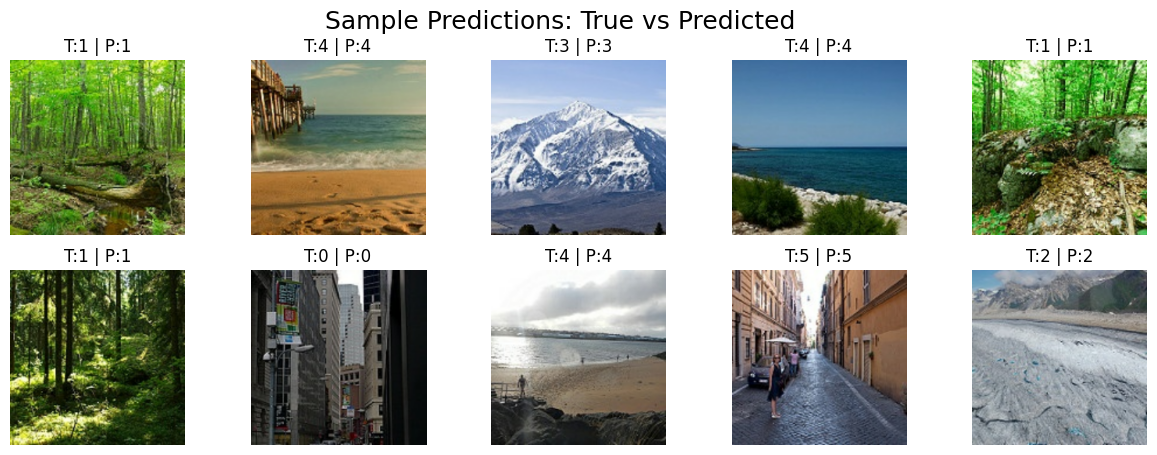

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
num_samples = 10
sample_images_display = []
sample_images_model = []
sample_true = []
for images, labels in test_ds:
    for i in range(len(images)):
        if len(sample_images_display) < num_samples:
            img_norm = images[i].numpy()
            img_display = (img_norm * 255).astype(np.uint8)
            sample_images_model.append(img_norm)
            sample_images_display.append(img_display)
            sample_true.append(labels[i].numpy())
        else:
            break
    if len(sample_images_display) >= num_samples:
        break
sample_images_tensor = np.stack(sample_images_model, axis=0)
pred_probs = model.predict(sample_images_tensor)
sample_pred = np.argmax(pred_probs, axis=1)
plt.figure(figsize=(15,5))
for i in range(num_samples):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample_images_display[i])
    plt.title(f"T:{sample_true[i]} | P:{sample_pred[i]}")
    plt.axis("off")

plt.suptitle("Sample Predictions: True vs Predicted", fontsize=18)
plt.show()
